# ***0 - Setting_environment***

In [7]:
import pandas as pd
import os
from tqdm import tqdm

# Path Kaggle dataset
DATA_PATH = "/kaggle/input/datasets/quanghtrngduy/mooccubex-dataset/"

print(os.listdir(DATA_PATH))

problem_file = os.path.join(
    DATA_PATH,
    "user-problem.json"
)

video_file = os.path.join(
    DATA_PATH,
    "user-video.json"
)

comment_file = os.path.join(
    DATA_PATH,
    "user-comment.txt"
)

reply_file = os.path.join(
    DATA_PATH,
    "reply.json"
)

['course-teacher.txt', 'course.json', 'paper.json', 'reply.json', 'concept-comment.txt', 'user-video.json', 'course-comment.txt', 'concept-problem.txt', 'user-reply.txt', 'school.json', 'translated_reply.json', 'video.json', 'concept-video.txt', 'other.json', 'course-school.txt', 'problem.json', 'user-comment.txt', 'user.json', 'exercise-problem.txt', 'concept-paper.txt', 'translated_comment.json', 'reply-reply.txt', 'course-field.json', 'video_id-ccid.txt', 'concept-reply.json', 'user-xiaomu.json', 'user-problem.json', 'concept.json', 'comment-reply.txt', 'teacher.json', 'concept-other.txt']


***problem_stats:***

In [8]:
problem_chunks = pd.read_json(
    problem_file,
    lines=True,
    chunksize=100000
)

problem_list = []

for chunk in tqdm(problem_chunks):

    stats = chunk.groupby("user_id").agg({
        "problem_id": "count",
        "is_correct": "mean",
        "attempts": "mean"
    })

    stats.columns = [
        "total_problems",
        "accuracy",
        "avg_attempts"
    ]

    problem_list.append(stats)

problem_stats = pd.concat(problem_list)

# gộp lại theo user
problem_stats = problem_stats.groupby(
    "user_id"
).agg({
    "total_problems": "sum",
    "accuracy": "mean",
    "avg_attempts": "mean"
}).reset_index()

print(problem_stats.shape)

problem_stats.to_csv(
    "/kaggle/working/problem_stats.csv",
    index=False
)

1334it [17:17,  1.29it/s]


(1290530, 4)


In [ ]:
problem_stats.head()

In [ ]:
problem_stats["user_id"].nunique()

***video_stats:***

In [4]:
video_chunks = pd.read_json(
    video_file,
    lines=True,
    chunksize=5
)

first_chunk = next(video_chunks)

print(first_chunk.columns)
first_chunk.head()

Index(['seq', 'user_id'], dtype='object')


,seq,user_id
0,"[{'video_id': 'V_1395633', 'segment': [{'start...",U_112
1,"[{'video_id': 'V_6224262', 'segment': [{'start...",U_150
2,"[{'video_id': 'V_6432959', 'segment': [{'start...",U_172
3,"[{'video_id': 'V_6334508', 'segment': [{'start...",U_189
4,"[{'video_id': 'V_1358540', 'segment': [{'start...",U_197


In [10]:
import pandas as pd
from tqdm import tqdm

video_chunks = pd.read_json(
    video_file,
    lines=True,
    chunksize=50000
)

video_list = []

for chunk in tqdm(video_chunks):

    user_stats = []

    for _, row in chunk.iterrows():

        user_id = row["user_id"]
        seq = row["seq"]

        video_watch_count = 0
        unique_video_set = set()
        total_watch_time = 0

        for item in seq:

            video_id = item.get("video_id")
            unique_video_set.add(video_id)

            if "segment" in item:

                segments = item["segment"]

                # Đếm số lần bấm video
                video_watch_count += len(segments)

                # Tính thời gian xem
                for seg in segments:

                    start = seg.get("start_point", 0)
                    end = seg.get("end_point", 0)

                    duration = max(end-start, 0)

                    total_watch_time += duration

        unique_videos = len(unique_video_set)

        user_stats.append({
            "user_id": user_id,
            "video_watch_count": video_watch_count,
            "unique_videos": unique_videos,
            "total_watch_time": total_watch_time
        })

    video_list.append(pd.DataFrame(user_stats))

video_stats = pd.concat(video_list)

video_stats = video_stats.groupby(
    "user_id"
).sum().reset_index()

print(video_stats.shape)

video_stats.to_csv(
    "/kaggle/working/video_stats.csv",
    index=False
)

7it [02:35, 22.24s/it]


(310360, 4)


In [8]:
video_stats.head()

,user_id,video_watch_count,unique_videos,total_watch_time
0,U_10001181,37,1,2878.000
1,U_10001587,28,4,8180.300
2,U_1000290,16,4,2311.700
3,U_1000342,12,2,60.000
4,U_1000454,2,2,495.119


***comment_stats:***

In [12]:
import pandas as pd

test = pd.read_csv(
    comment_file,
    sep="\t",
    nrows=5
)

print(test.columns)
test.head()

Index(['U_10030806', 'Cm_1'], dtype='object')


,U_10030806,Cm_1
0,U_1705400,Cm_4
1,U_10031537,Cm_5
2,U_10031502,Cm_7
3,U_10031397,Cm_12
4,U_10031397,Cm_13


In [11]:
import pandas as pd
from tqdm import tqdm

comment_file = "/kaggle/input/datasets/quanghtrngduy/mooccubex-dataset/user-comment.txt"

comment_chunks = pd.read_csv(
    comment_file,
    sep="\t",
    header=None,
    names=["user_id", "comment_id"],
    chunksize=200000
)

comment_list = []

for chunk in tqdm(comment_chunks):

    stats = chunk.groupby(
        "user_id"
    ).agg(
        total_comments=("comment_id", "count")
    )

    comment_list.append(stats)

comment_stats = pd.concat(comment_list)

comment_stats = comment_stats.groupby(
    "user_id"
).sum().reset_index()

print(comment_stats.shape)

comment_stats.to_csv(
    "/kaggle/working/comment_stats.csv",
    index=False
)

43it [00:11,  3.83it/s]


(873784, 2)


In [15]:
comment_stats.head()

,user_id,total_comments
0,U_10000423,1
1,U_10000657,4
2,U_10000780,1
3,U_10000789,5
4,U_10000837,8


***reply_stats:***

In [12]:
reply_file = "/kaggle/input/datasets/quanghtrngduy/mooccubex-dataset/user-reply.txt"

reply_chunks = pd.read_csv(
    reply_file,
    sep="\t",
    header=None,
    names=["user_id", "reply_id"],
    chunksize=200000
)

reply_list = []

for chunk in tqdm(reply_chunks):

    stats = chunk.groupby(
        "user_id"
    ).agg(
        total_replies=("reply_id", "count")
    )

    reply_list.append(stats)

reply_stats = pd.concat(reply_list)

reply_stats = reply_stats.groupby(
    "user_id"
).sum().reset_index()

print(reply_stats.shape)

reply_stats.to_csv(
    "/kaggle/working/reply_stats.csv",
    index=False
)

2it [00:00,  5.80it/s]


(50313, 2)


In [17]:
reply_stats.head()

,user_id,total_replies
0,U_10000657,1
1,U_10000676,1
2,U_10000837,1
3,U_10001364,2
4,U_10001453,1


# ***1 - Load data***

In [9]:
import pandas as pd
import os
from tqdm import tqdm

# Path Kaggle dataset
DATA_PATH = "/kaggle/input/datasets/sonnguyenthanh014689/moocccubex-modified-sonnguyen/"

print(os.listdir(DATA_PATH))

['comment_stats.csv', 'problem_stats.csv', 'video_stats.csv', 'reply_stats.csv']


# ***2 - Merge and featuring***

In [10]:
#Import data từ file csv
import pandas as pd

problem_stats = pd.read_csv(
    "/kaggle/input/datasets/sonnguyenthanh014689/moocccubex-modified-sonnguyen/problem_stats.csv"
)

video_stats = pd.read_csv(
    "/kaggle/input/datasets/sonnguyenthanh014689/moocccubex-modified-sonnguyen/video_stats.csv"
)

comment_stats = pd.read_csv(
    "/kaggle/input/datasets/sonnguyenthanh014689/moocccubex-modified-sonnguyen/comment_stats.csv"
)

reply_stats = pd.read_csv(
    "/kaggle/input/datasets/sonnguyenthanh014689/moocccubex-modified-sonnguyen/reply_stats.csv"
)

In [11]:
print(problem_stats.shape)
print(video_stats.shape)
print(comment_stats.shape)
print(reply_stats.shape)

(1290530, 4)
(310360, 4)
(873784, 2)
(50313, 2)


***Merge:***

In [13]:
user_features = problem_stats.merge(
    video_stats,
    on="user_id",
    how="outer"
)

user_features = user_features.merge(
    comment_stats,
    on="user_id",
    how="outer"
)

user_features = user_features.merge(
    reply_stats,
    on="user_id",
    how="outer"
)

print(user_features.shape)

(1704998, 9)


***Xử lý missing values:***

In [14]:
user_features = user_features.fillna(0)

***Ép kiểu về integer:***

In [16]:
int_columns = [
    "total_problems",
    "video_watch_count",
    "unique_videos",
    "total_watch_time",
    "total_comments",
    "total_replies"
]

for col in int_columns:
    if col in user_features.columns:
        user_features[col] = user_features[col].astype("int64")

In [17]:
user_features.head()

,user_id,total_problems,accuracy,avg_attempts,video_watch_count,unique_videos,total_watch_time,total_comments,total_replies
0,U_10000,7,0.142857,1.000000,0,0,0,0,0
1,U_10000130,21,0.000000,1.666667,0,0,0,0,0
2,U_10000242,12,0.000000,1.000000,0,0,0,0,0
3,U_1000038,5,0.400000,1.000000,0,0,0,0,0
4,U_10000423,16,0.125000,1.375000,0,0,0,1,0


In [18]:
user_features.describe()

,total_problems,accuracy,avg_attempts,video_watch_count,unique_videos,total_watch_time,total_comments,total_replies
count,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06
mean,7.823137e+01,6.024342e-01,7.848498e-01,1.510187e+01,1.161879e+00,3.621363e+02,4.939674e+00,1.941416e-01
std,1.434864e+02,3.993042e-01,4.770124e-01,5.585847e+02,4.991275e+00,3.198210e+03,2.273650e+01,2.517537e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.600000e+01,7.750000e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,9.700000e+01,9.583333e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00
max,2.274300e+04,1.000000e+00,3.993750e+01,1.287740e+05,3.560000e+02,6.419720e+05,2.002100e+04,2.247700e+04


In [26]:
user_features["user_id"].nunique()

1704998

In [28]:
print(user_features.shape)

print("Video users:",
      (user_features["video_watch_count"] > 0).sum())

print("Comment users:",
      (user_features["total_comments"] > 0).sum())

print("Reply users:",
      (user_features["total_replies"] > 0).sum())

user_features.describe()

(1704998, 9)
Video users: 310360
Comment users: 873784
Reply users: 50313


,total_problems,accuracy,avg_attempts,video_watch_count,unique_videos,total_watch_time,total_comments,total_replies
count,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06
mean,7.823137e+01,6.024342e-01,7.848498e-01,1.510187e+01,1.161879e+00,2.837714e+02,4.939674e+00,1.941416e-01
std,1.434864e+02,3.993042e-01,4.770124e-01,5.585847e+02,4.991275e+00,5.250635e+04,2.273650e+01,2.517537e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.714359e+07,0.000000e+00,0.000000e+00
25%,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.600000e+01,7.750000e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,9.700000e+01,9.583333e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00
max,2.274300e+04,1.000000e+00,3.993750e+01,1.287740e+05,3.560000e+02,6.419720e+05,2.002100e+04,2.247700e+04


In [29]:
user_features[
    user_features["user_id"] == "U_1000290"
]

,user_id,total_problems,accuracy,avg_attempts,video_watch_count,unique_videos,total_watch_time,total_comments,total_replies
223,U_1000290,53,1.0,1.0,16,4,2311,0,0


In [36]:
user_features["total_watch_time"].min()

0

In [37]:
user_features.describe()

,total_problems,accuracy,avg_attempts,video_watch_count,unique_videos,total_watch_time,total_comments,total_replies
count,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06
mean,7.823137e+01,6.024342e-01,7.848498e-01,1.510187e+01,1.161879e+00,3.621360e+02,4.939674e+00,1.941416e-01
std,1.434864e+02,3.993042e-01,4.770124e-01,5.585847e+02,4.991275e+00,3.198210e+03,2.273650e+01,2.517537e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.600000e+01,7.750000e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,9.700000e+01,9.583333e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00
max,2.274300e+04,1.000000e+00,3.993750e+01,1.287740e+05,3.560000e+02,6.419720e+05,2.002100e+04,2.247700e+04


In [19]:
#To csv
user_features.to_csv(
    "/kaggle/working/user_features.csv",
    index=False
)

# ***3 - Chương5. EDA Visualization***

***Histogram — total_problems***

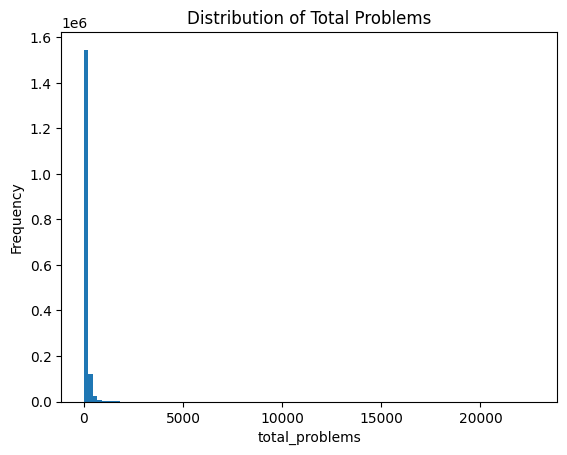

In [38]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(
    user_features["total_problems"],
    bins=100
)

plt.title("Distribution of Total Problems")

plt.xlabel("total_problems")
plt.ylabel("Frequency")

plt.show()

***Histogram — video_watch_count***

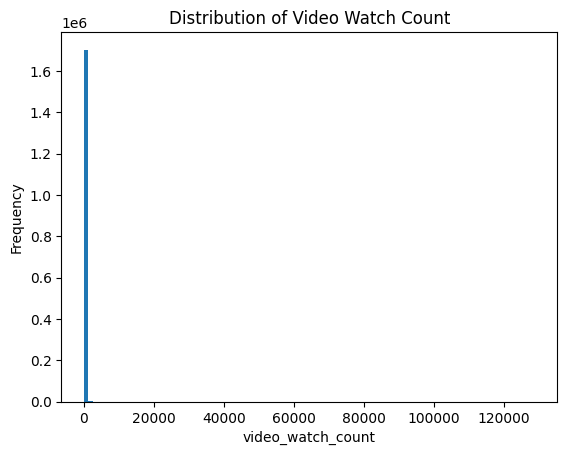

In [39]:
plt.figure()

plt.hist(
    user_features["video_watch_count"],
    bins=100
)

plt.title("Distribution of Video Watch Count")

plt.xlabel("video_watch_count")
plt.ylabel("Frequency")

plt.show()

***Histogram — total_watch_time***

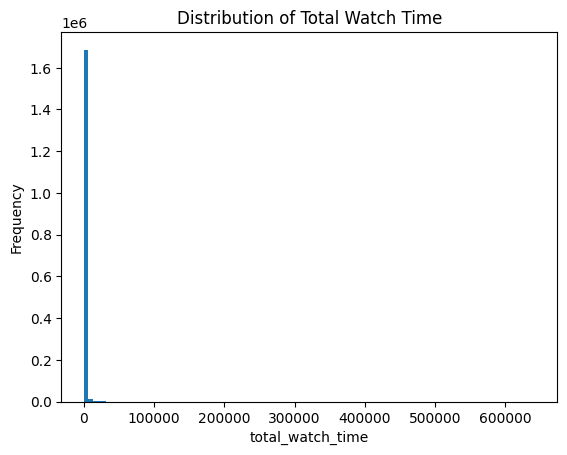

In [40]:
plt.figure()

plt.hist(
    user_features["total_watch_time"],
    bins=100
)

plt.title("Distribution of Total Watch Time")

plt.xlabel("total_watch_time")
plt.ylabel("Frequency")

plt.show()

***Correlation Matrix***

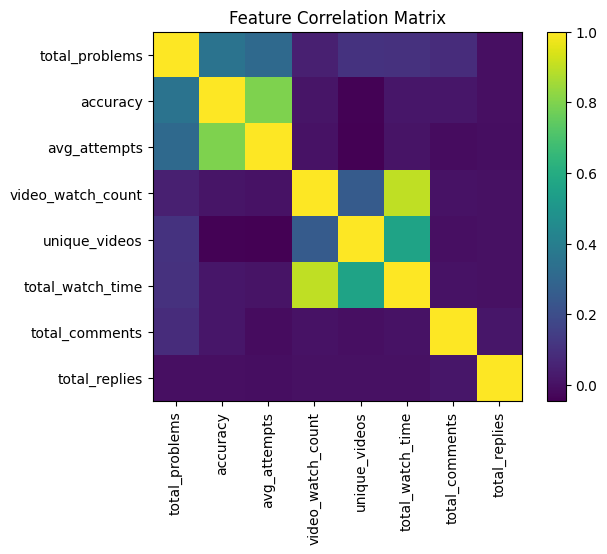

In [41]:
corr = user_features.corr(numeric_only=True)

plt.figure()

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Feature Correlation Matrix")

plt.show()

(array([1.686653e+06, 1.255300e+04, 3.121000e+03, 1.124000e+03,
        4.800000e+02, 2.420000e+02, 1.380000e+02, 1.020000e+02,
        7.600000e+01, 5.300000e+01, 3.800000e+01, 3.600000e+01,
        3.000000e+01, 3.300000e+01, 3.700000e+01, 2.100000e+01,
        2.600000e+01, 2.300000e+01, 1.400000e+01, 1.100000e+01,
        8.000000e+00, 1.500000e+01, 1.300000e+01, 1.400000e+01,
        8.000000e+00, 5.000000e+00, 9.000000e+00, 5.000000e+00,
        3.000000e+00, 6.000000e+00, 5.000000e+00, 7.000000e+00,
        7.000000e+00, 6.000000e+00, 2.000000e+00, 6.000000e+00,
        4.000000e+00, 8.000000e+00, 6.000000e+00, 4.000000e+00,
        5.000000e+00, 4.000000e+00, 2.000000e+00, 1.000000e+00,
        3.000000e+00, 2.000000e+00, 0.000000e+00, 1.000000e+00,
        4.000000e+00, 0.000000e+00, 1.000000e+00, 2.000000e+00,
        1.000000e+00, 0.000000e+00, 1.000000e+00, 2.000000e+00,
        4.000000e+00, 2.000000e+00, 0.000000e+00, 2.000000e+00,
        1.000000e+00, 0.000000e+00, 0.00

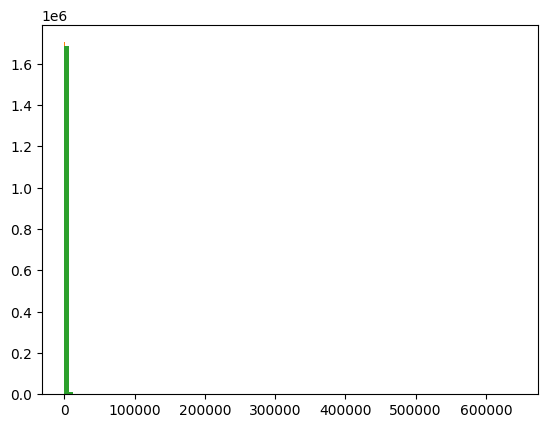

In [42]:
plt.hist(user_features["total_problems"], bins=100)

plt.hist(user_features["video_watch_count"], bins=100)

plt.hist(user_features["total_watch_time"], bins=100)

In [43]:
corr = user_features.corr(numeric_only=True)
print(corr)

                   total_problems  accuracy  avg_attempts  video_watch_count  \
total_problems           1.000000  0.353493      0.313006           0.044906   
accuracy                 0.353493  1.000000      0.796947           0.012303   
avg_attempts             0.313006  0.796947      1.000000           0.006175   
video_watch_count        0.044906  0.012303      0.006175           1.000000   
unique_videos            0.107293 -0.042025     -0.046234           0.254183   
total_watch_time         0.102615  0.015171      0.007192           0.899605   
total_comments           0.086471  0.016858     -0.010526           0.003418   
total_replies           -0.001493 -0.004927     -0.005976          -0.000151   

                   unique_videos  total_watch_time  total_comments  \
total_problems          0.107293          0.102615        0.086471   
accuracy               -0.042025          0.015171        0.016858   
avg_attempts           -0.046234          0.007192       -0.010526   

***Scatter Plot — video vs problem***

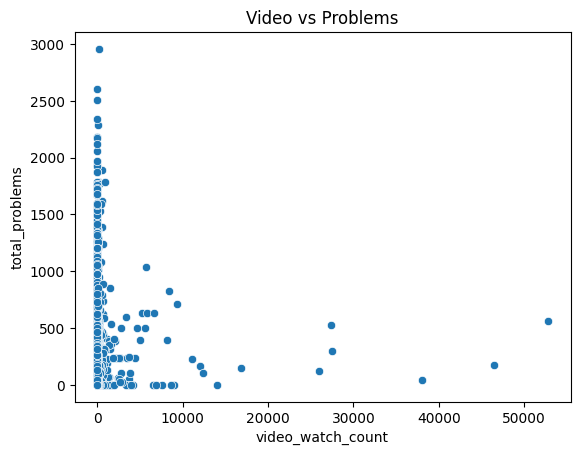

In [47]:
import seaborn as sns
plt.figure()

sns.scatterplot(
    x="video_watch_count",
    y="total_problems",
    data=user_features.sample(50000)
)

plt.title("Video vs Problems")

plt.show()

***Scatter plot giữa số bài làm và độ chính xác***

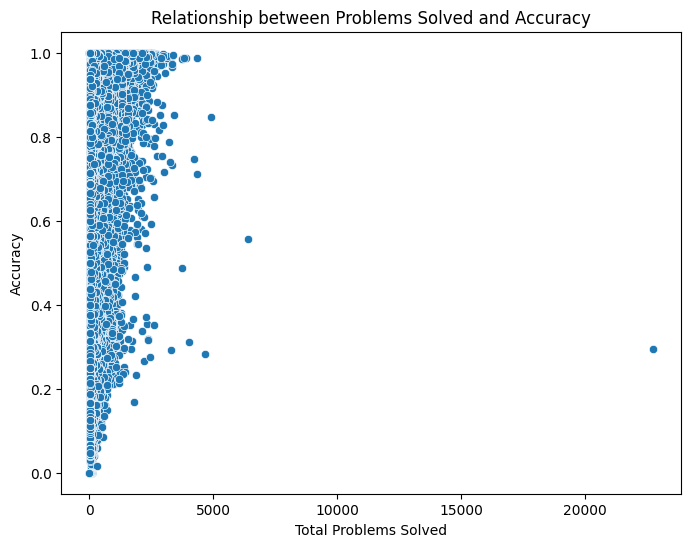

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=user_features["total_problems"],
    y=user_features["accuracy"]
)

plt.xlabel("Total Problems Solved")
plt.ylabel("Accuracy")
plt.title("Relationship between Problems Solved and Accuracy")

plt.show()

***Scatter plot giữa số bài làm và số lần thử trung bình***

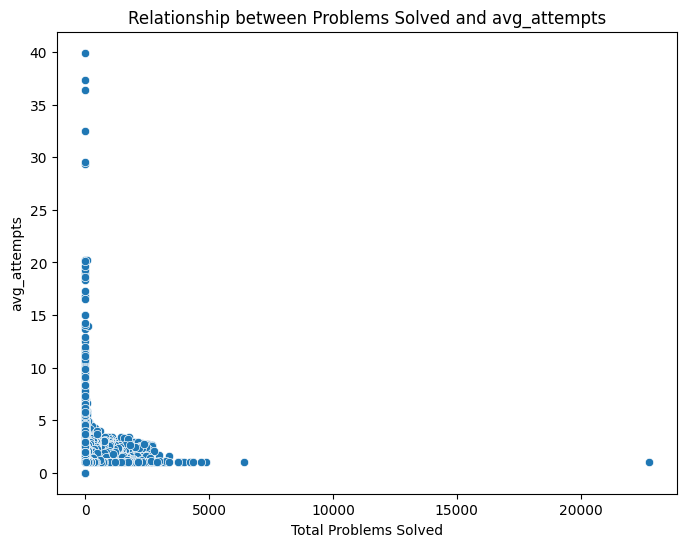

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=user_features["total_problems"],
    y=user_features["avg_attempts"]
)

plt.xlabel("Total Problems Solved")
plt.ylabel("avg_attempts")
plt.title("Relationship between Problems Solved and avg_attempts")

plt.show()

***Heatmap — correlation***

All columns:
Index(['user_id', 'total_problems', 'accuracy', 'avg_attempts',
       'video_watch_count', 'unique_videos', 'total_watch_time',
       'total_comments', 'total_replies'],
      dtype='object')

Numeric columns:
Index(['total_problems', 'accuracy', 'avg_attempts', 'video_watch_count',
       'unique_videos', 'total_watch_time', 'total_comments', 'total_replies'],
      dtype='object')


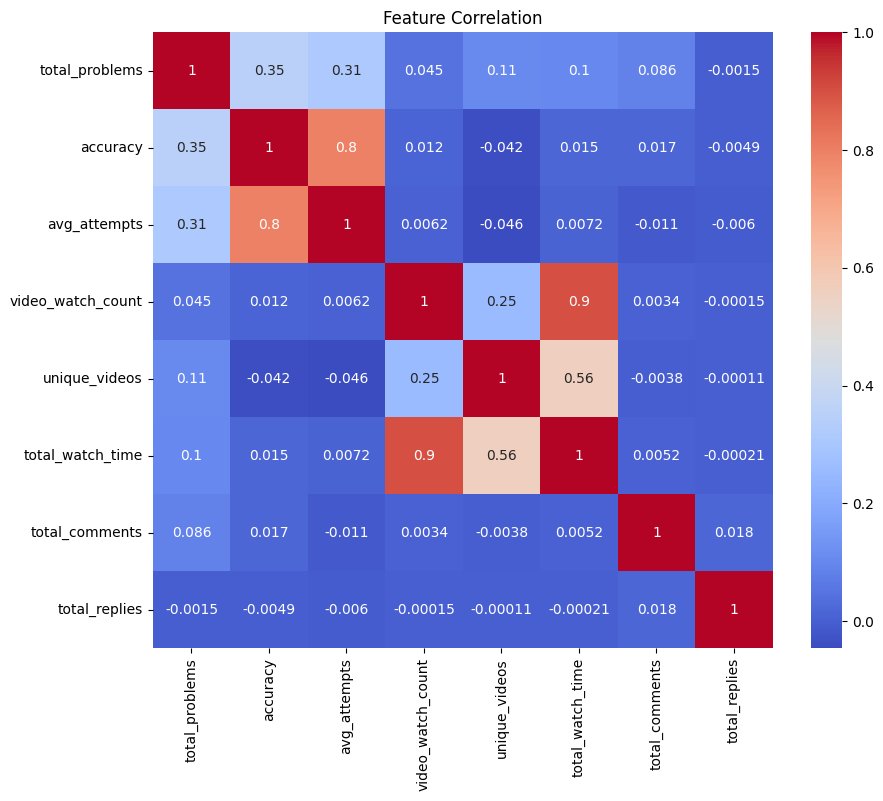

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1️⃣ Kiểm tra columns trước
print("All columns:")
print(user_features.columns)

# 2️⃣ Chỉ lấy các cột numeric
numeric_df = user_features.select_dtypes(include=[np.number])

print("\nNumeric columns:")
print(numeric_df.columns)

# 3️⃣ Vẽ Heatmap correlation
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

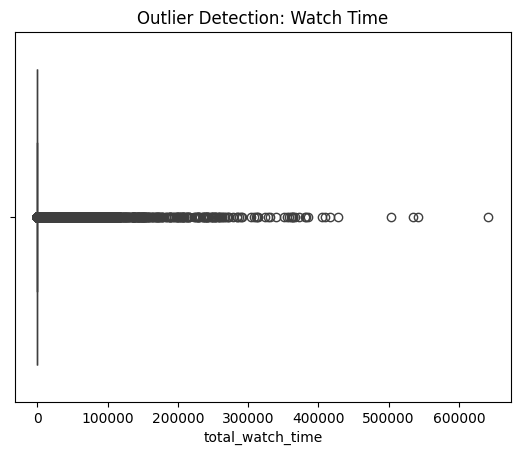

In [51]:
plt.figure()

sns.boxplot(
    x=user_features["total_watch_time"]
)

plt.title("Outlier Detection: Watch Time")

plt.show()

***Boxplot — phát hiện outlier***

***Phát hiện dữ liệu bất thường***

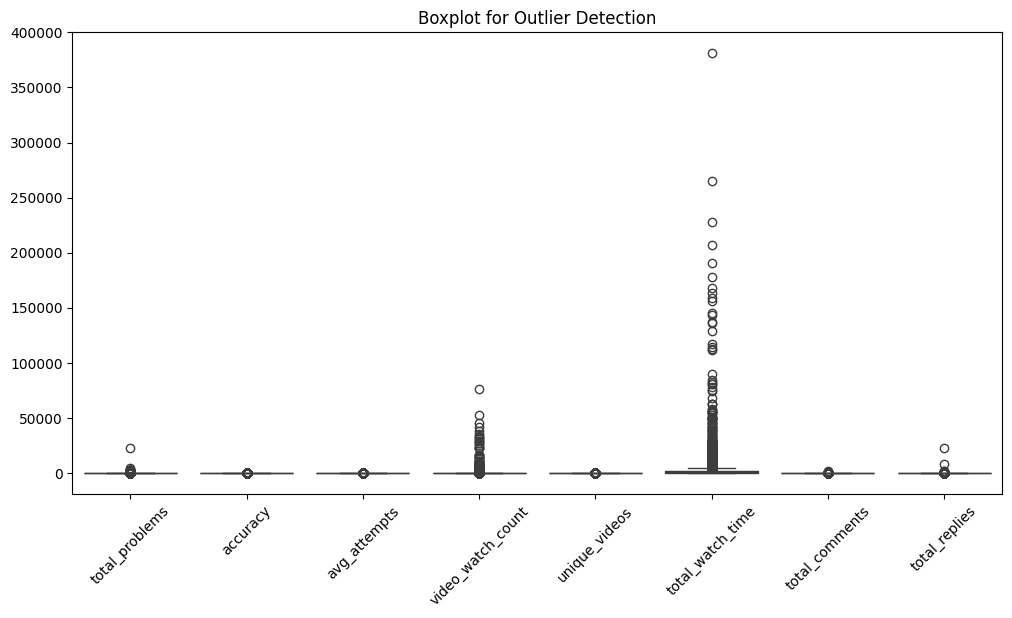

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1️⃣ Chỉ lấy cột numeric (bỏ user_id)
numeric_df = user_features.select_dtypes(include=[np.number])

# 2️⃣ Lấy sample để tránh crash RAM
sample_df = numeric_df.sample(100000, random_state=42)

# 3️⃣ Vẽ boxplot
plt.figure(figsize=(12,6))

sns.boxplot(data=sample_df)

plt.xticks(rotation=45)

plt.title("Boxplot for Outlier Detection")

plt.show()

***Log Transform***

In [18]:
import numpy as np

log_df = numeric_df.copy()

cols_to_log = [
    "video_watch_count",
    "total_watch_time",
    "total_comments",
    "total_replies",
    "total_problems"
]

for col in cols_to_log:
    log_df[col] = np.log1p(log_df[col])

***boxplot with Log transform***

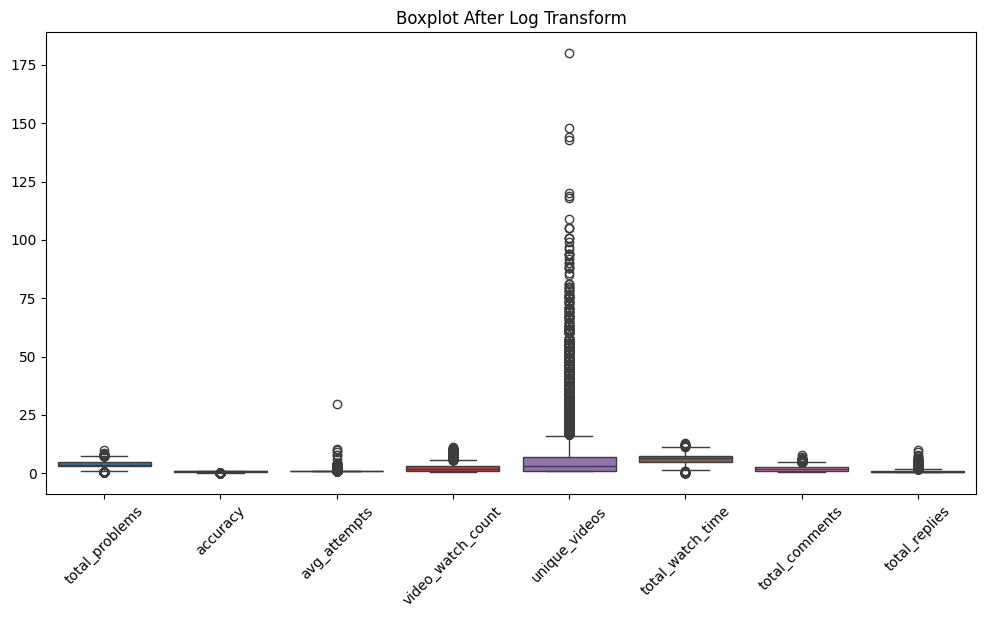

In [19]:
sample_log_df = log_df.sample(100000, random_state=42)

plt.figure(figsize=(12,6))

sns.boxplot(data=sample_log_df)

plt.xticks(rotation=45)

plt.title("Boxplot After Log Transform")

plt.show()

***Pairplot phân tích đa biến***

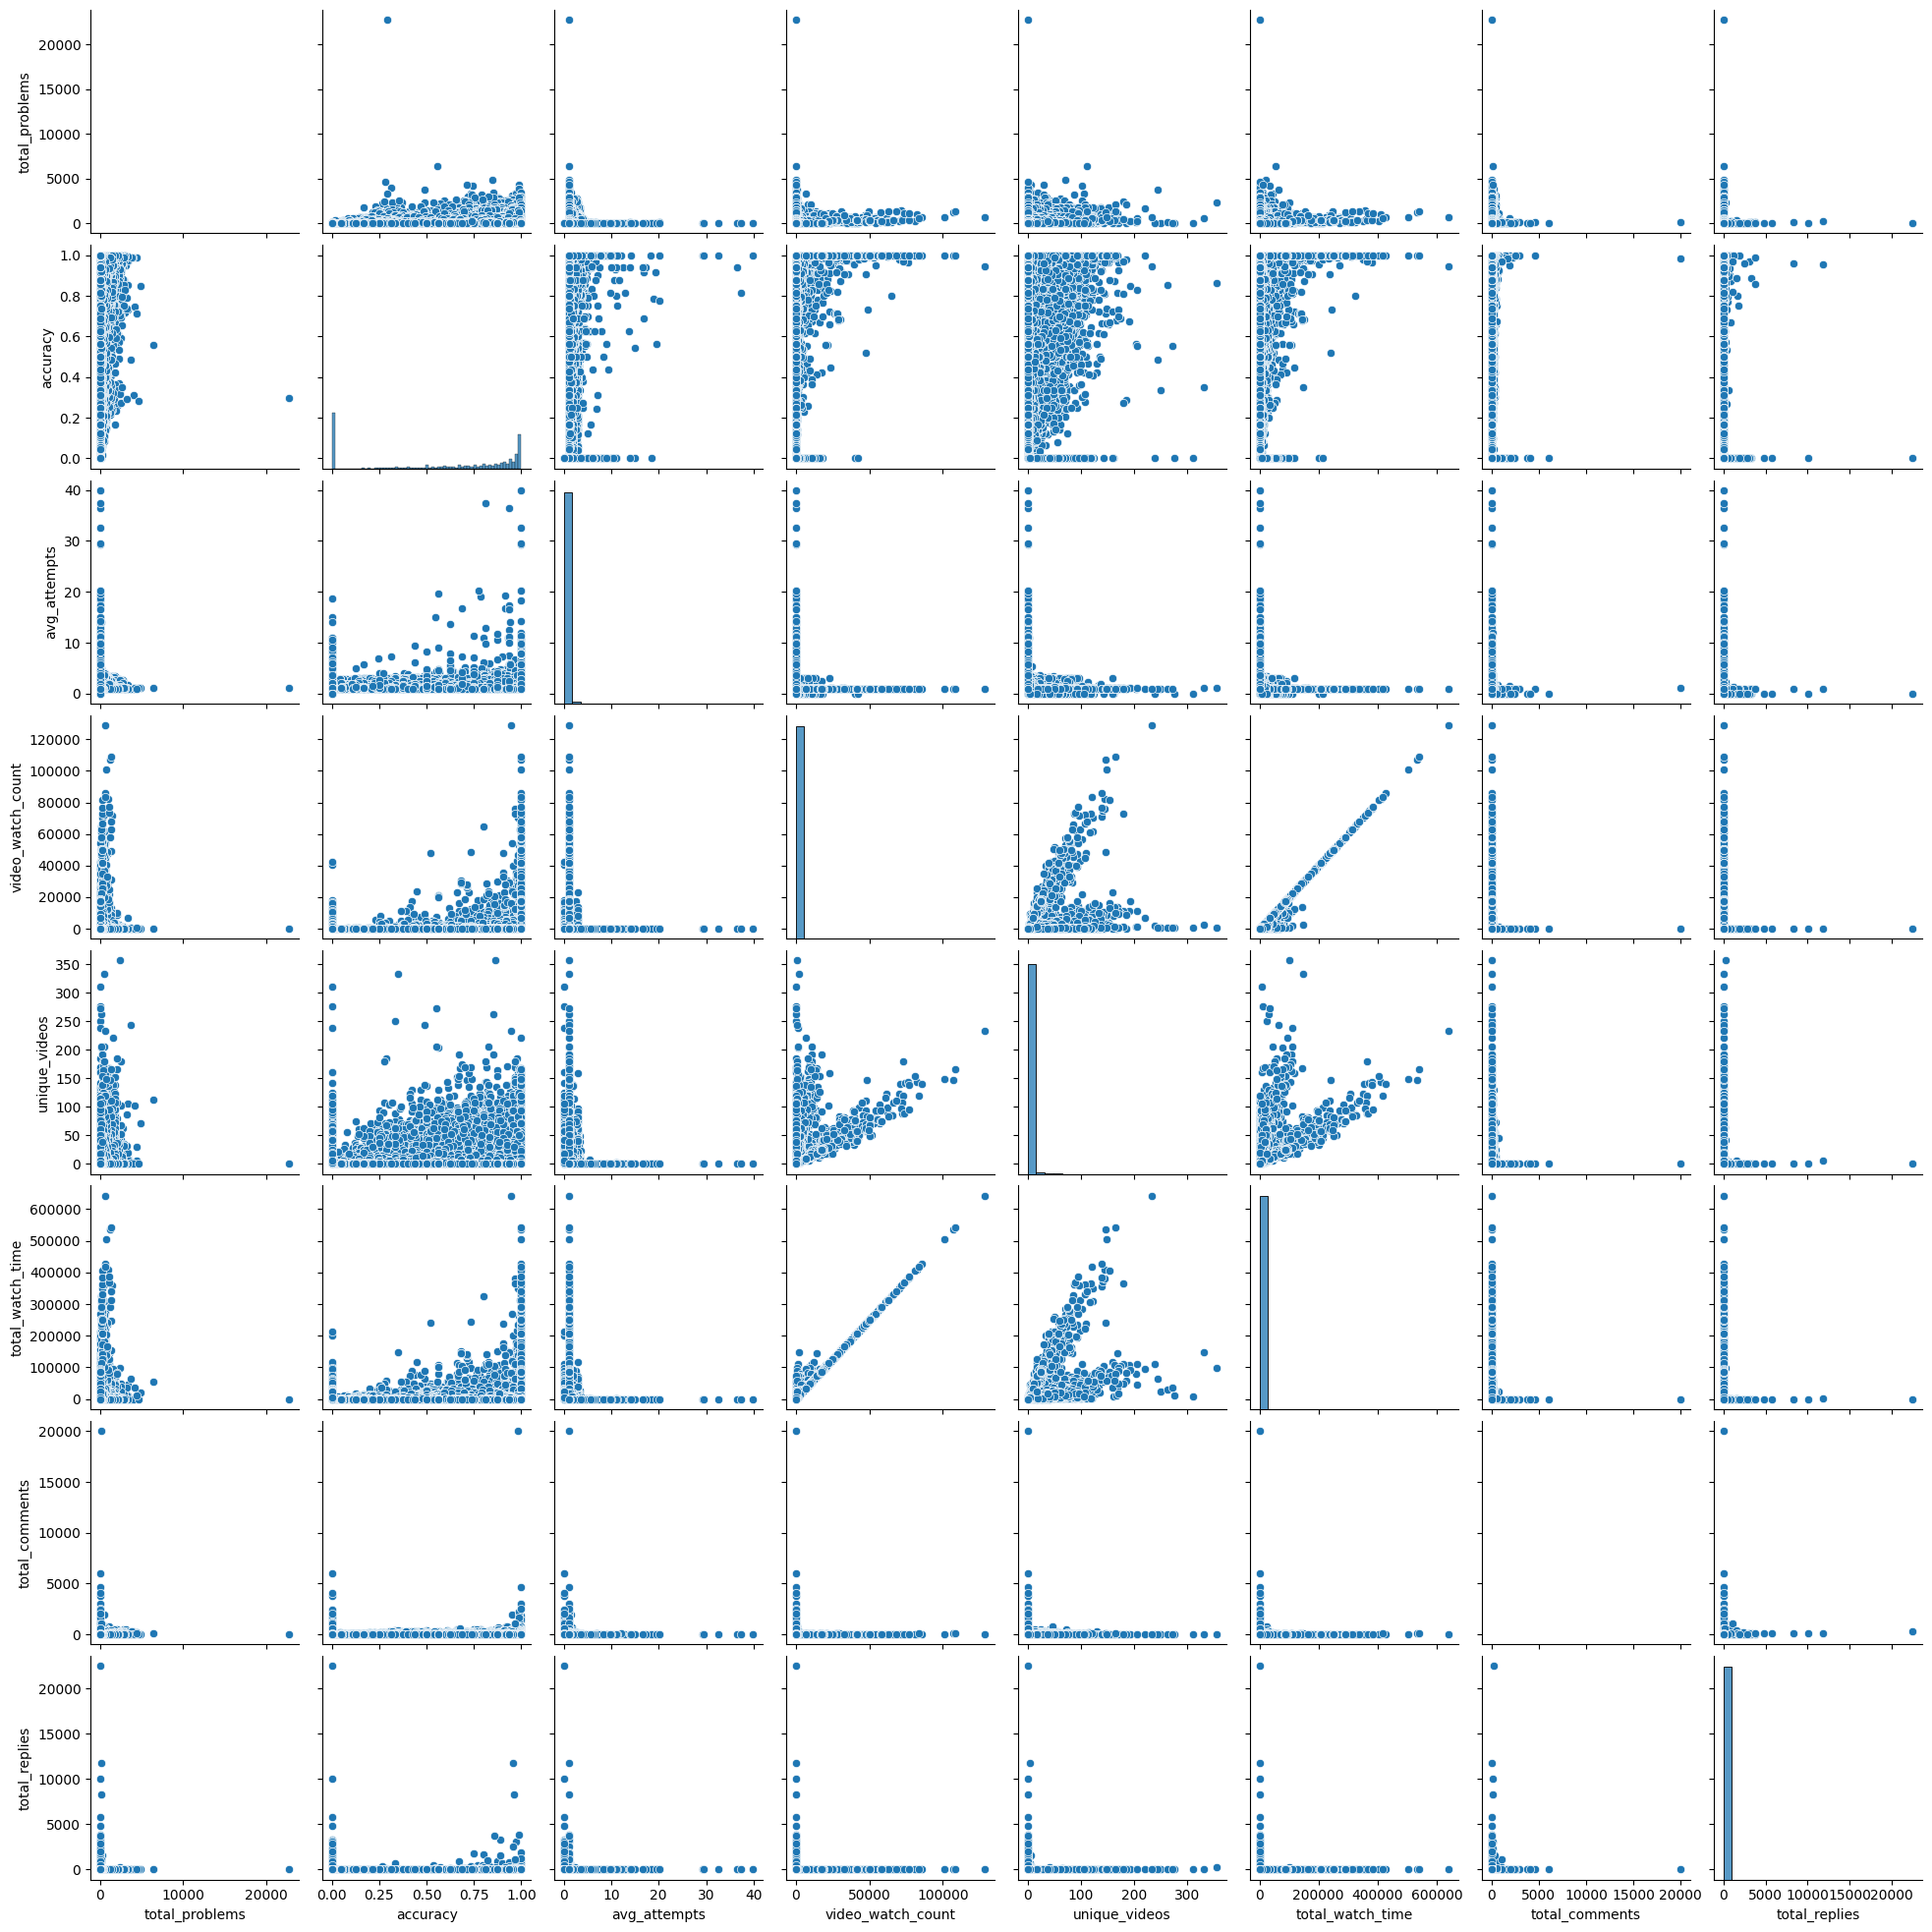

In [57]:
sns.pairplot(user_features)

plt.show()

***Biểu đồ phân bố dữ liệu***

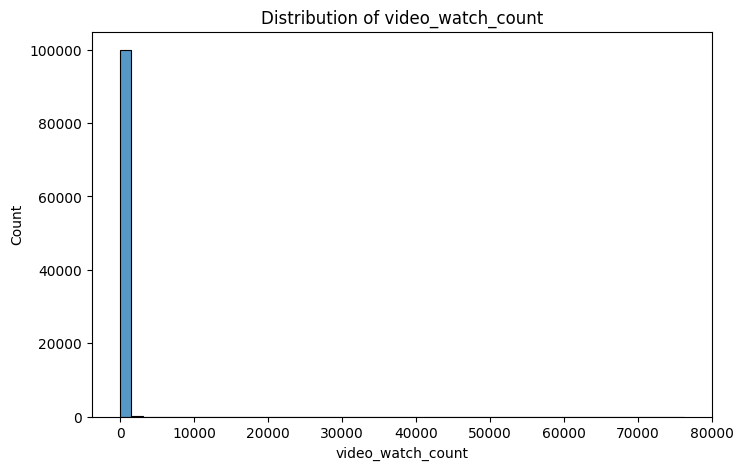

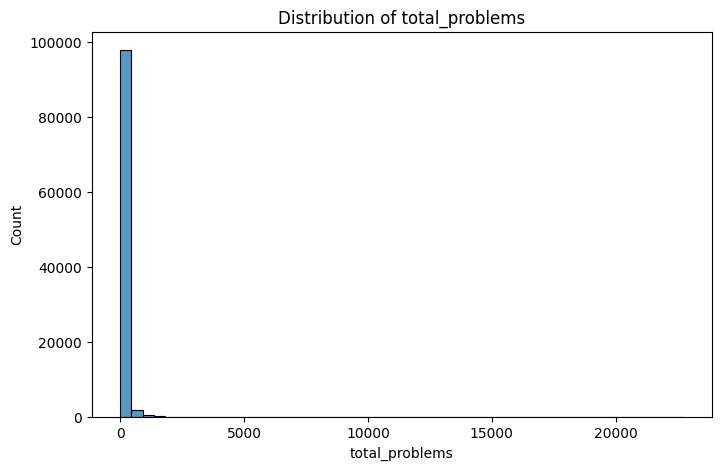

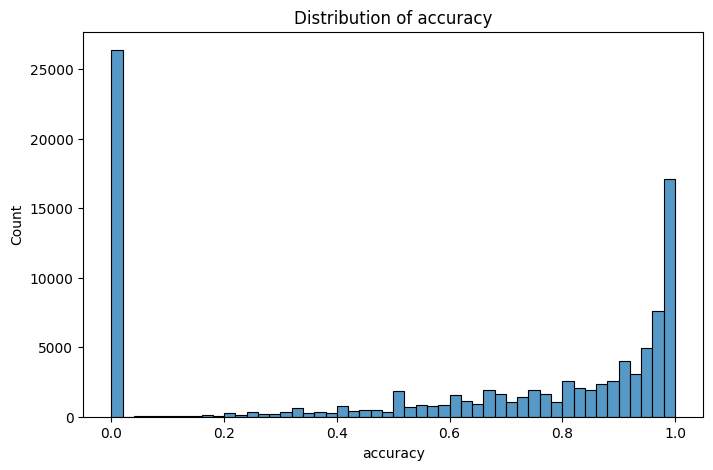

In [60]:
features = [
    "video_watch_count",
    "total_problems",
    "accuracy"
]

sample_df = user_features.sample(100000, random_state=42)

for col in features:
    plt.figure(figsize=(8,5))
    
    sns.histplot(
        sample_df[col],
        bins=50
    )
    
    plt.title(f"Distribution of {col}")
    plt.show()

In [16]:
print(user_features.columns)

Index(['user_id', 'total_problems', 'accuracy', 'avg_attempts',
       'video_watch_count', 'unique_videos', 'total_watch_time',
       'total_comments', 'total_replies'],
      dtype='object')


***Final Visualization - histograms***

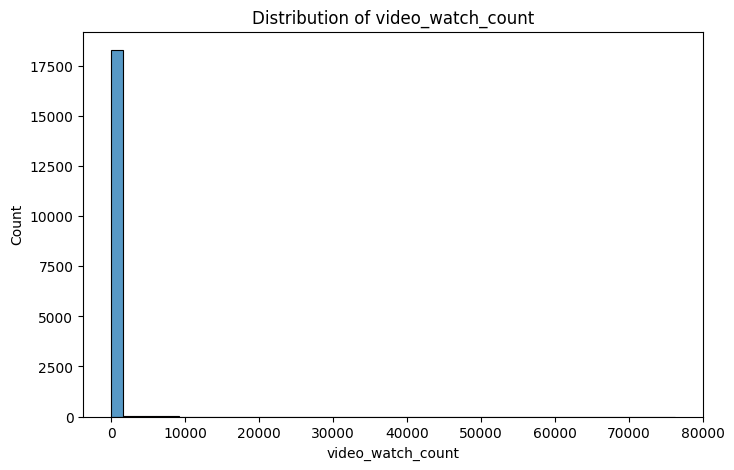

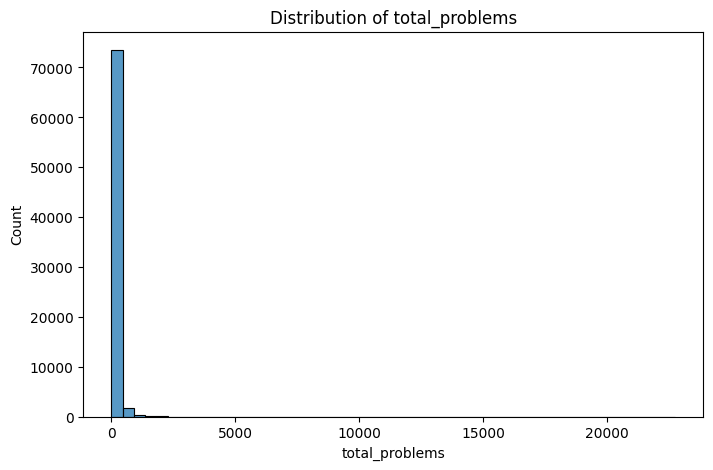

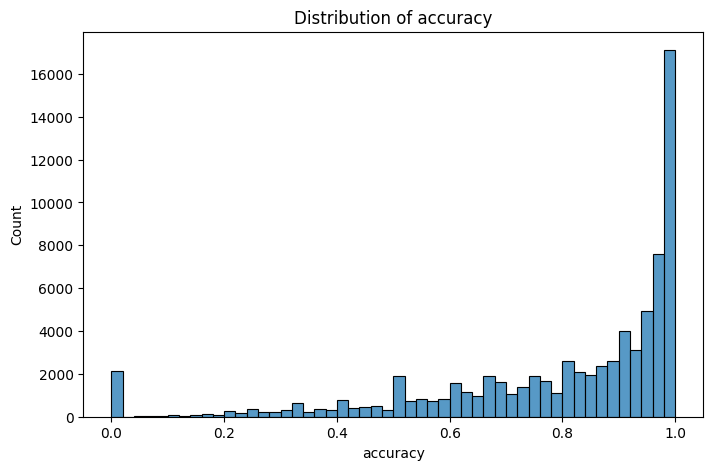

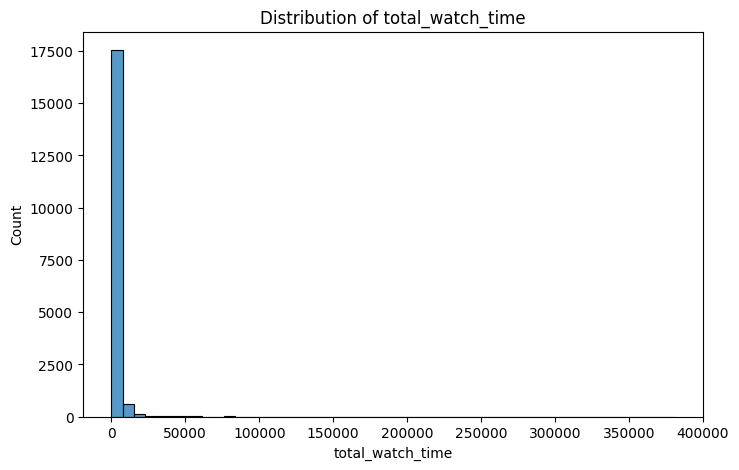

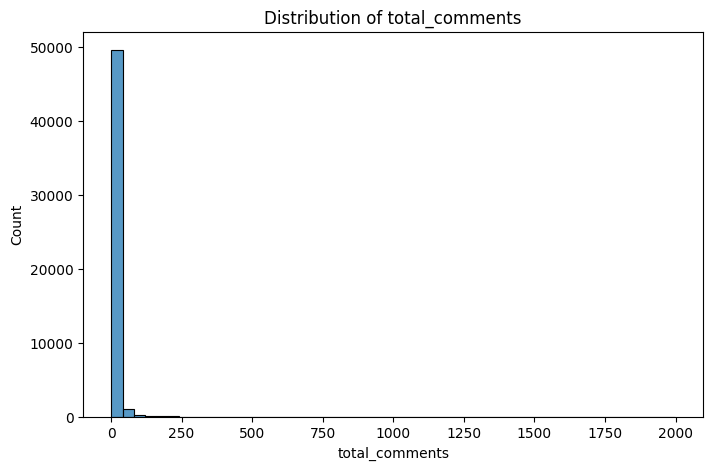

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample để tránh crash RAM
sample_df = user_features.sample(100000, random_state=42)

cols = [
    "video_watch_count",
    "total_problems",
    "accuracy",
    "total_watch_time",
    "total_comments"
]

for col in cols:

    plt.figure(figsize=(8,5))

    sns.histplot(
        sample_df[col],
        bins=50
    )

    plt.title(f"Distribution of {col}")

    plt.show()

***Final Visualization - Scatter Plot***

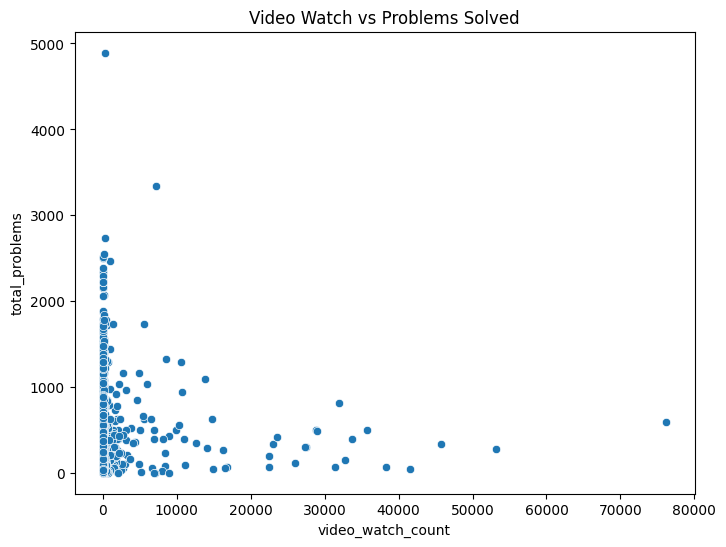

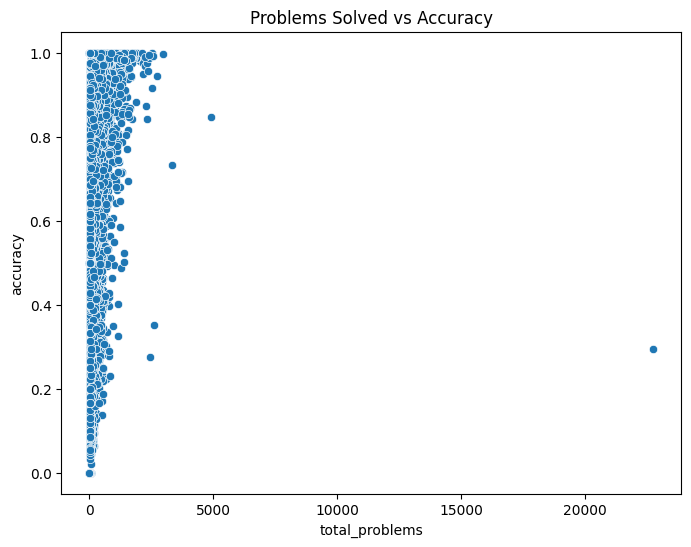

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=sample_df["video_watch_count"],
    y=sample_df["total_problems"]
)

plt.title("Video Watch vs Problems Solved")

plt.show()

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=sample_df["total_problems"],
    y=sample_df["accuracy"]
)

plt.title("Problems Solved vs Accuracy")

plt.show()

***Final Visualization - Heatmap Correlation***

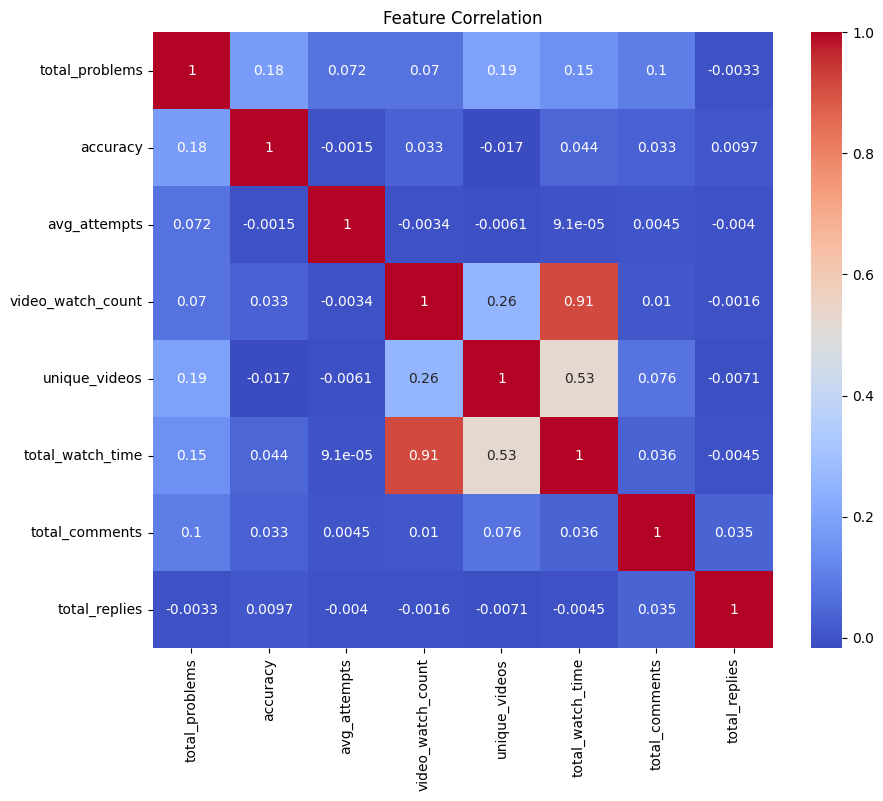

In [23]:
import numpy as np

numeric_df = user_features.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

***Final Visualization - Boxplot***

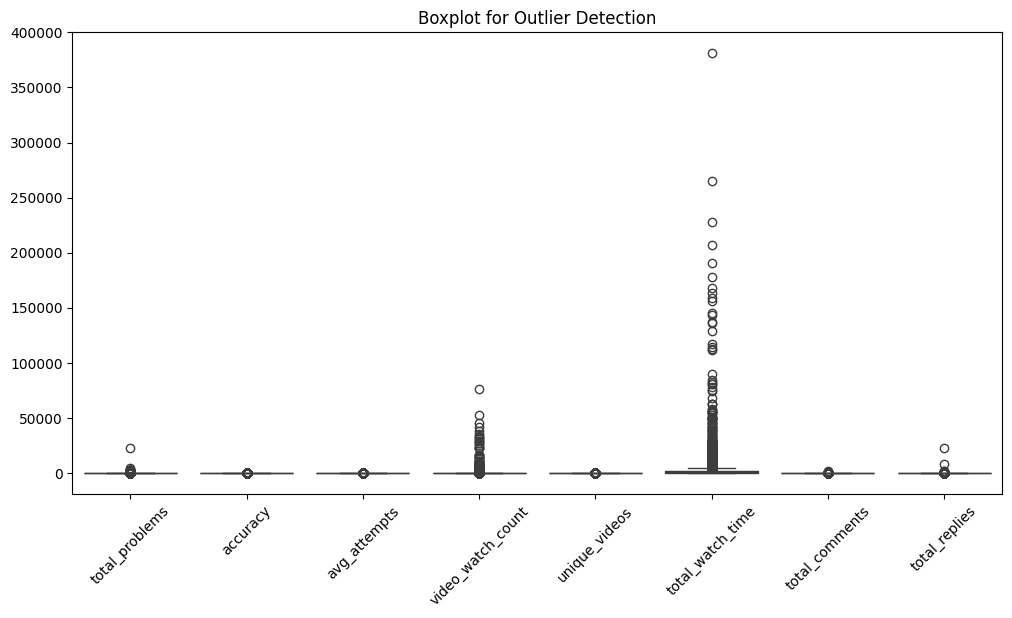

In [24]:
import numpy as np

numeric_df = user_features.select_dtypes(include=[np.number])

sample_df = numeric_df.sample(100000, random_state=42)

plt.figure(figsize=(12,6))

sns.boxplot(data=sample_df)

plt.xticks(rotation=45)

plt.title("Boxplot for Outlier Detection")

plt.show()

# ***4 - Chương 6. Preprocessing***

***Kiểm tra Missing Values***

In [1]:
# Kiểm tra missing values

import pandas as pd

user_features = pd.read_csv(
    "/kaggle/input/datasets/sonnguyenthanh014689/moocccubex-modified-sonnguyen/user_features.csv"
)

missing = user_features.isnull().sum()

print(missing)

user_id              0
total_problems       0
accuracy             0
avg_attempts         0
video_watch_count    0
unique_videos        0
total_watch_time     0
total_comments       0
total_replies        0
dtype: int64


***Kiểm tra Duplicate***

In [2]:
duplicate_count = user_features.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


***Phát hiện Outliers***

In [3]:
import numpy as np

numeric_df = user_features.select_dtypes(include=[np.number])

numeric_df.describe()

,total_problems,accuracy,avg_attempts,video_watch_count,unique_videos,total_watch_time,total_comments,total_replies
count,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06
mean,7.823137e+01,6.024342e-01,7.848498e-01,1.510187e+01,1.161879e+00,3.621363e+02,4.939674e+00,1.941416e-01
std,1.434864e+02,3.993042e-01,4.770124e-01,5.585847e+02,4.991275e+00,3.198210e+03,2.273650e+01,2.517537e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.600000e+01,7.750000e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,9.700000e+01,9.583333e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00
max,2.274300e+04,1.000000e+00,3.993750e+01,1.287740e+05,3.560000e+02,6.419720e+05,2.002100e+04,2.247700e+04


***Log Transform and Feature Scaling***

In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Step 1: Numeric data
numeric_df = user_features.select_dtypes(include=[np.number])

# Step 2: Log transform
cols_to_log = [
    "total_problems",
    "video_watch_count",
    "total_watch_time",
    "total_comments",
    "total_replies"
]

log_df = numeric_df.copy()

for col in cols_to_log:
    log_df[col] = np.log1p(log_df[col])

# Step 3: Clip outliers
for col in log_df.columns:

    lower = log_df[col].quantile(0.01)
    upper = log_df[col].quantile(0.99)

    log_df[col] = log_df[col].clip(lower, upper)

# Step 4: Scaling
scaler = StandardScaler()

scaled_data = scaler.fit_transform(log_df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=log_df.columns
)

print("Preprocessing completed.")

Preprocessing completed.


In [11]:
scaled_df.describe()

,total_problems,accuracy,avg_attempts,video_watch_count,unique_videos,total_watch_time,total_comments,total_replies
count,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06,1.704998e+06
mean,-7.584688e-17,2.093040e-16,-7.044591e-16,1.580282e-17,-3.160564e-17,-6.004406e-17,7.236292e-16,1.642293e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.459784e+00,-1.508711e+00,-1.717410e+00,-4.072439e-01,-3.031965e-01,-4.488287e-01,-8.370566e-01,-1.743743e-01
25%,-1.115915e+00,-1.508711e+00,4.839415e-01,-4.072439e-01,-3.031965e-01,-4.488287e-01,-8.370566e-01,-1.743743e-01
50%,3.315818e-01,4.321663e-01,4.839415e-01,-4.072439e-01,-3.031965e-01,-4.488287e-01,-2.254438e-01,-1.743743e-01
75%,8.148048e-01,8.912985e-01,4.839415e-01,-4.072439e-01,-3.031965e-01,-4.488287e-01,7.439396e-01,-1.743743e-01
max,1.748822e+00,9.956467e-01,2.133376e+00,4.301854e+00,6.490882e+00,3.059554e+00,2.578778e+00,5.734791e+00


***Export data after preprocessing***

In [12]:
import joblib

# Save scaled dataset
scaled_df.to_parquet(
    "scaled_user_features.parquet",
    index=False
)

# Save sample
sample_df = scaled_df.sample(
    n=100000,
    random_state=42
)

sample_df.to_parquet(
    "sample_scaled_features.parquet",
    index=False
)

# Save scaler
joblib.dump(
    scaler,
    "standard_scaler.pkl"
)

print("All files saved successfully.")

All files saved successfully.


# ***5 - Chương 8. PHÂN TÍCH THỐNG KÊ (STATISTICAL ANALYSIS)***

***Phân tích tương quan***

In [7]:
import os
DATA_PATH = "/kaggle/input/datasets/sonnguyenthanh014689/moocccubex-modified-sonnguyen/"

print(os.listdir(DATA_PATH))

['comment_stats.csv', 'user_features.csv', 'problem_stats.csv', 'scaled_user_features.parquet', 'sample_scaled_features.parquet', 'video_stats.csv', 'standard_scaler.pkl', 'reply_stats.csv']


In [1]:
import pandas as pd

scaled_df = pd.read_parquet(
    "/kaggle/input/datasets/sonnguyenthanh014689/moocccubex-modified-sonnguyen/scaled_user_features.parquet"
)

print(scaled_df.shape)
print(scaled_df.head())
print(scaled_df.columns)

(1704998, 8)
   total_problems  accuracy  avg_attempts  video_watch_count  unique_videos  \
0       -0.428179 -1.150945      0.483941          -0.407244      -0.303196   
1        0.073673 -1.508711      1.951509          -0.407244      -0.303196   
2       -0.187320 -1.508711      0.483941          -0.407244      -0.303196   
3       -0.570897 -0.506968      0.483941          -0.407244      -0.303196   
4       -0.054235 -1.195666      1.309448          -0.407244      -0.303196   

   total_watch_time  total_comments  total_replies  
0         -0.448829       -0.837057      -0.174374  
1         -0.448829       -0.837057      -0.174374  
2         -0.448829       -0.837057      -0.174374  
3         -0.448829       -0.837057      -0.174374  
4         -0.448829       -0.225444      -0.174374  
Index(['total_problems', 'accuracy', 'avg_attempts', 'video_watch_count',
       'unique_videos', 'total_watch_time', 'total_comments', 'total_replies'],
      dtype='object')


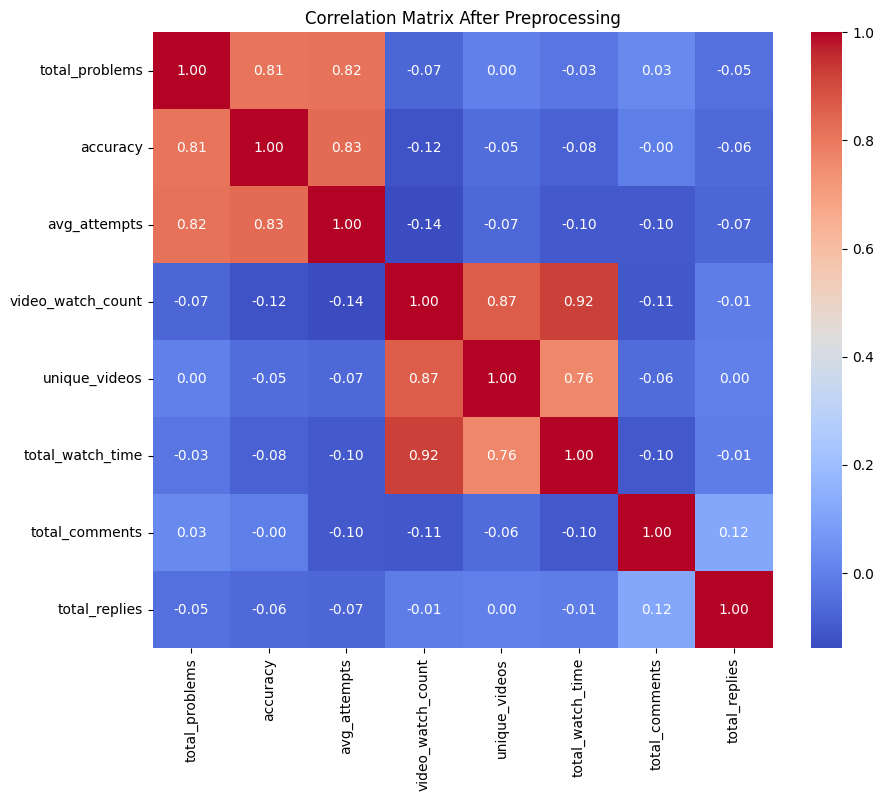

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

corr = scaled_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix After Preprocessing")

plt.show()

***Phân bố dữ liệu sau chuẩn hóa***

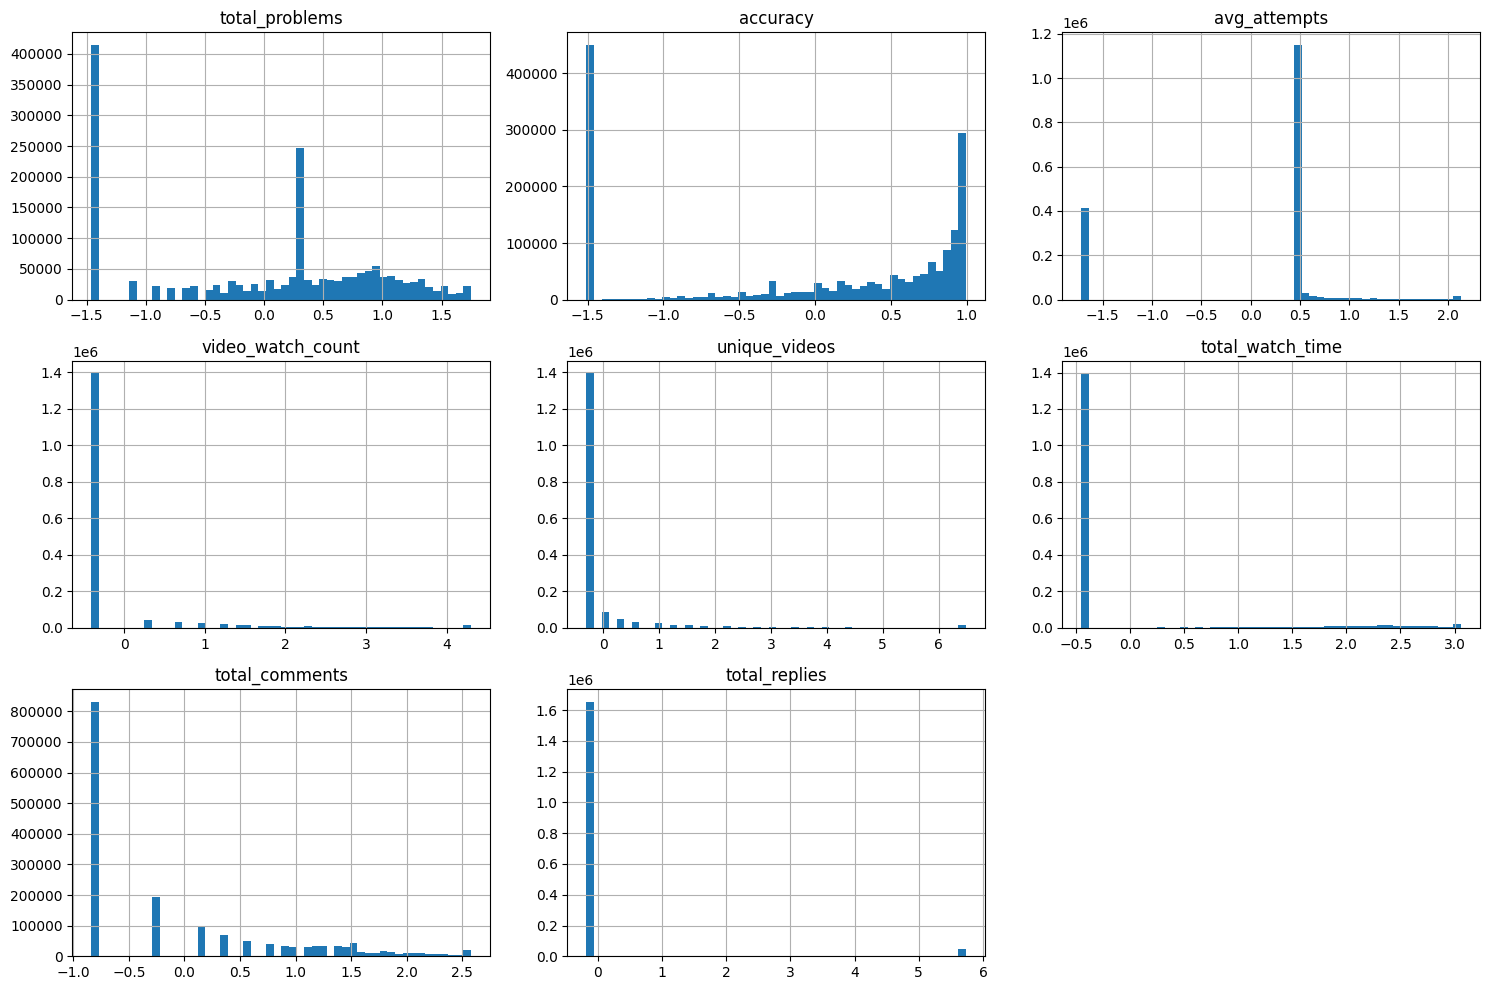

In [11]:
scaled_df.hist(
    bins=50,
    figsize=(15,10)
)

plt.tight_layout()

plt.show()

***So sánh hệ số tương quan Pearson và Spearman***

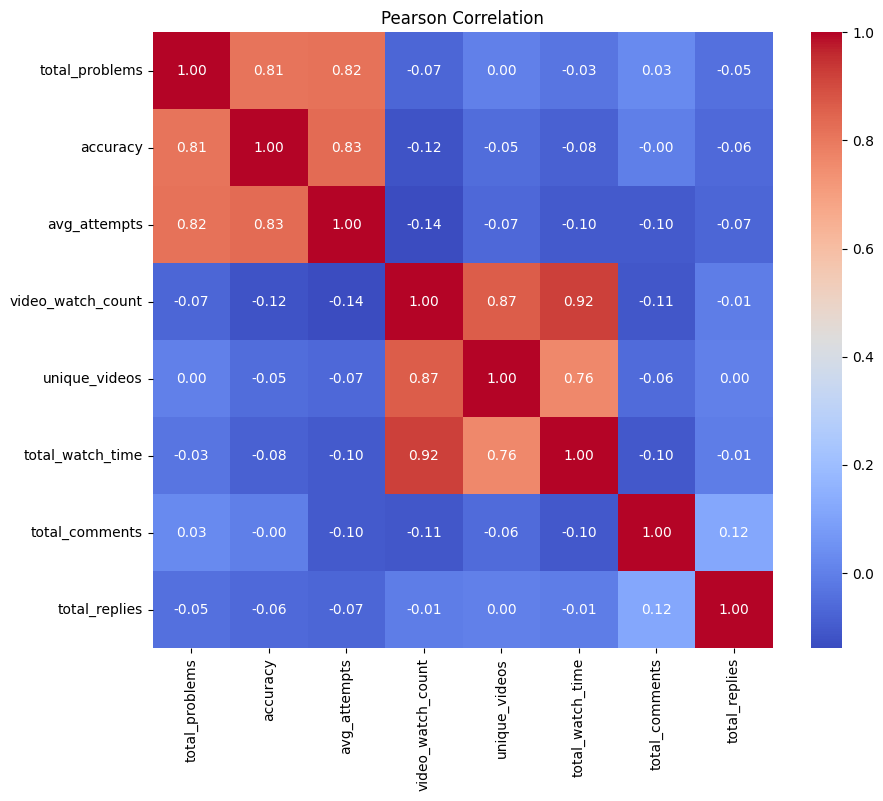

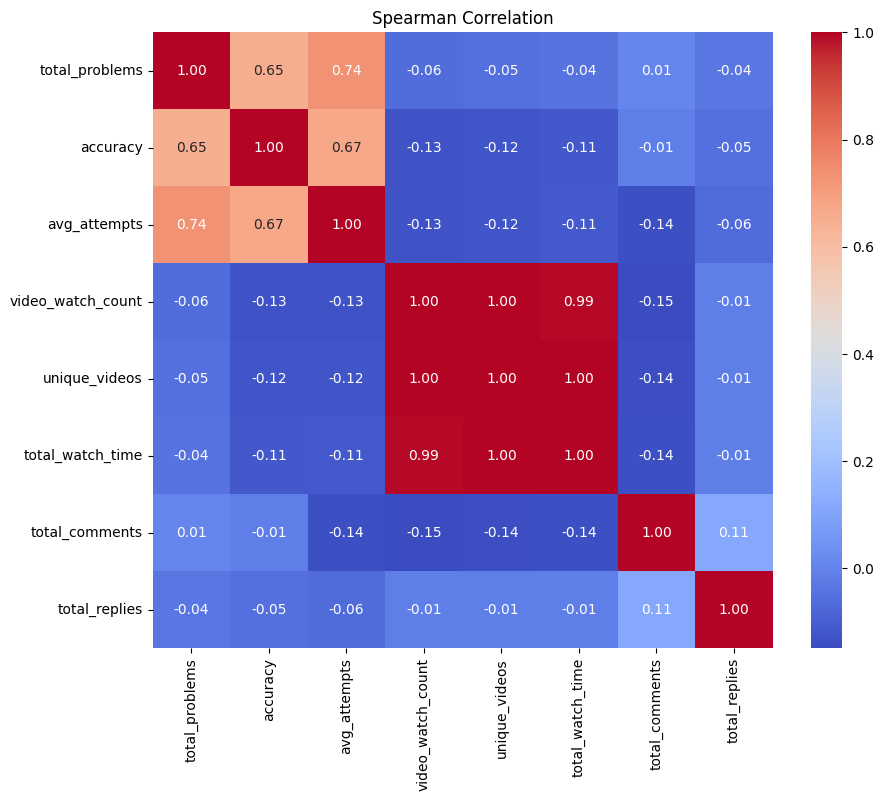

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

pearson_corr = scaled_df.corr(method="pearson")

spearman_corr = scaled_df.corr(method="spearman")

# Pearson
plt.figure(figsize=(10,8))
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation")
plt.show()

# Spearman
plt.figure(figsize=(10,8))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Spearman Correlation")
plt.show()

# ***6 - Chương 9. GIẢM CHIỀU DỮ LIỆU (PCA)***

***Xác định số thành phần chính***

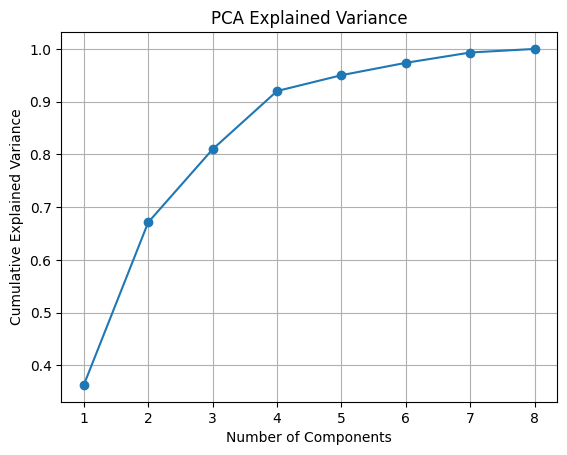

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(scaled_df)

explained_variance = pca.explained_variance_ratio_

plt.figure()

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance.cumsum(),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid()

plt.show()

***Áp dụng PCA***

In [4]:
pca = PCA(n_components=4)

pca_data = pca.fit_transform(scaled_df)

import pandas as pd

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2", "PC3", "PC4"]
)

print(pca_df.head())

        PC1       PC2       PC3       PC4
0 -0.074348 -0.820671 -0.882651  0.549948
1 -0.685481 -0.119876 -0.892742  0.648840
2 -0.023108 -0.865884 -0.879085  0.545314
3 -0.269403 -0.607945 -0.859486  0.548413
4 -0.538204 -0.376072 -0.440731  0.177365


***Trực quan hóa PCA***

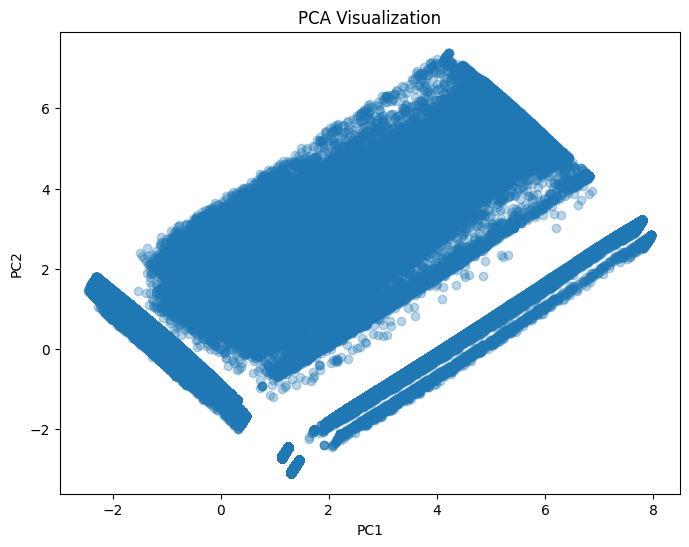

In [5]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.3
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Visualization")

plt.show()

# ***7 - Chương 10. Khai phá tri thức***


***Xác định số cụm bằng Elbow Method***


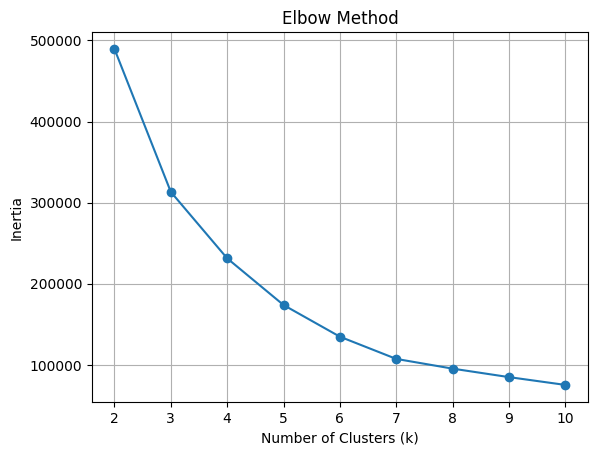

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Chọn dữ liệu cho clustering
# Ưu tiên PCA, nếu không có thì dùng scaled_df
data_for_cluster = pca_df  # hoặc scaled_df

# Lấy mẫu để tăng tốc
sample_df = data_for_cluster.sample(100000, random_state=42)

inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(sample_df)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

***Xác nhận số cụm bằng Silhouette Score***

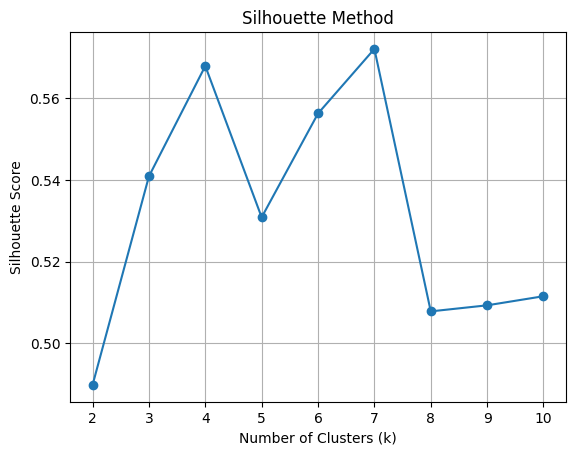

In [7]:
from sklearn.metrics import silhouette_score

sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(sample_df)
    score = silhouette_score(sample_df, labels)
    sil_scores.append(score)

plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.grid()
plt.show()

***Áp dụng K-Means và trực quan hóa kết quả phân cụm***

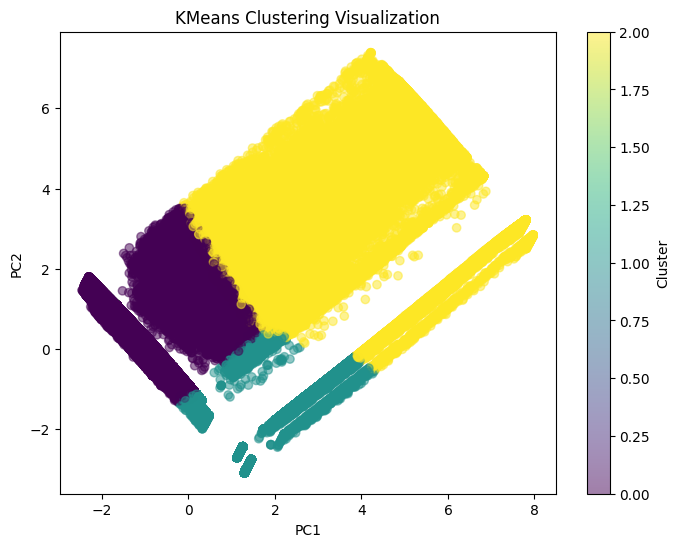

In [8]:
kmeans = KMeans(
    n_clusters=3,  # thay bằng k đã chọn
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(data_for_cluster)

# Lưu kết quả
cluster_df = data_for_cluster.copy()
cluster_df["cluster"] = labels

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=cluster_df["cluster"],
    cmap="viridis",
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering Visualization")

plt.colorbar(label="Cluster")

plt.show()

***Phân tích đặc trưng của từng cụm***

In [9]:
# Nếu dùng PCA để cluster, nên join lại với scaled_df để diễn giải dễ hơn
result_df = scaled_df.copy()
result_df["cluster"] = labels

cluster_summary = result_df.groupby("cluster").mean()

print(cluster_summary)

         total_problems  accuracy  avg_attempts  video_watch_count  \
cluster                                                              
0              0.473944  0.521784      0.552411          -0.364853   
1             -1.433727 -1.508601     -1.591352          -0.106698   
2              0.125985 -0.010534     -0.023549           2.489310   

         unique_videos  total_watch_time  total_comments  total_replies  
cluster                                                                  
0            -0.285828         -0.362571       -0.054256      -0.050472  
1            -0.201683         -0.095671        0.238071       0.147765  
2             2.202479          2.451607       -0.172414      -0.002909  
